# Pythonskript zur Einführung in Datenverarbeitung
In diesem Skript bekommen Sie eine Einführung in die Datenverarbeitung mit Python. 
Wir arbeiten mit dem einfachen Iris-Datensatz, sodass Sie in die Arbeit mit Python reinkommen können.
Wir werden typische Lage- und Streumaße berechnen, einen größeren zufälligen Datensatz mit Hilfe der Normalverteilung erstellen und eine Table 1 generieren, die Sie für Ihre Auswertungen in den einzelnen Projekten benötigen

In [2]:
#Zuerste laden wir die nötigen Packages und den Datensatz ein
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import iqr, norm
from tabulate import tabulate

iris = sns.load_dataset('iris')

iris.head()
#mit head() lassen wir uns die ersten 5 Zeilen eines Datensatzes anzeigen

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
#Einfache Deskription
#wir definieren eine eigene Funktion summary_stats, die die 
#Lage- und Streumaße berechnen kann.
#Wir sehen im head Befehl oben, dass es eine Spalte species gibt
#Um zu sehen, welche Arten an Spezies im Datensatz sind, führen folgenden Code aus:
print(iris['species'].unique())
#daraus sehen wir, dass es 3 verschiedene Spezies gibt
#da wir für die Übersicht jede Variable nehmen, brauchen wir in 
#der Funktion keine spezielle Spalte auswählen, sondern lassen uns
#die Maßzahlen aller Spalten ausgeben:

def summary_stats(df):
    """Berechnet Mittelwert, Median, SD"""
    stats = {}
    for col in df.select_dtypes(include=np.number).columns:
        mean = df[col].mean()
        median = df[col].median()
        std = df[col].std()
        inter_qr = iqr(df[col])
        stats[col] = {
            'Mean': round(mean, 2),
            'Median': round(median, 2),
            'SD': round(std, 2),
            'IQR': round(inter_qr,2)
        }
    return pd.DataFrame(stats).T

# Gruppieren nach Spezies und Statistik berechnen
# grouped_stats = iris.groupby('species').apply(summary_stats)

# python
# Variante A (empfohlen): nur numerische Spalten nach groupby übergeben
numeric_cols = iris.select_dtypes(include=np.number).columns
grouped_stats = iris.groupby('species')[numeric_cols].apply(summary_stats)

# Variante B: include_groups (nur wenn Ihre pandas-Version dieses Argument für groupby.apply unterstützt)
# grouped_stats = iris.groupby('species').apply(summary_stats, include_groups=False)


print("\nLage- und Streumaße je Spezies:")
print(grouped_stats)


['setosa' 'versicolor' 'virginica']

Lage- und Streumaße je Spezies:
                         Mean  Median    SD   IQR
species                                          
setosa     sepal_length  5.01    5.00  0.35  0.40
           sepal_width   3.43    3.40  0.38  0.48
           petal_length  1.46    1.50  0.17  0.18
           petal_width   0.25    0.20  0.11  0.10
versicolor sepal_length  5.94    5.90  0.52  0.70
           sepal_width   2.77    2.80  0.31  0.48
           petal_length  4.26    4.35  0.47  0.60
           petal_width   1.33    1.30  0.20  0.30
virginica  sepal_length  6.59    6.50  0.64  0.68
           sepal_width   2.97    3.00  0.32  0.38
           petal_length  5.55    5.55  0.55  0.78
           petal_width   2.03    2.00  0.27  0.50


In der Vorlesung haben wir gesehen, dass es eine Möglichkeit gibt, sich über die Normalverteilung, neue Werte erzeugen zu lassen, die die selbe Verteilung haben, wie unsere vorliegenden Daten.
Das testen wir anhand der sepal_length der Spezies Setosa

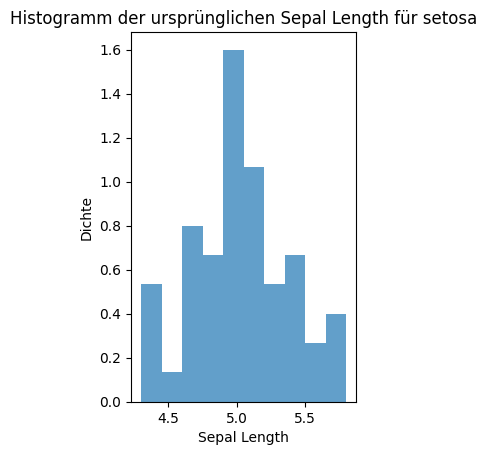

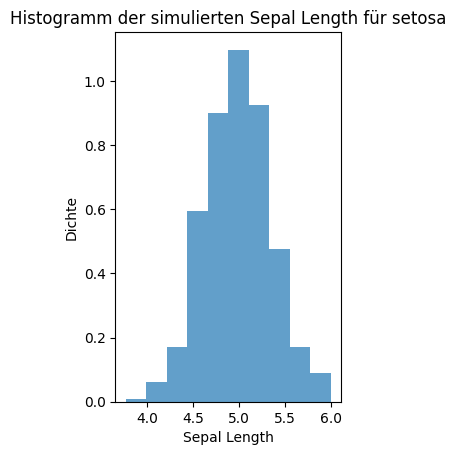

In [5]:
#wir ermitteln, wie viele Einträge es für Setosa gibt
len(iris[iris['species'] == 'setosa'])
#Aus unserer Berechnung oben wissen wir den Mittelwert und die
#Standardabweichung für die Sepal length
mean = grouped_stats.loc[('setosa','sepal_length'),'Mean']
sd = grouped_stats.loc[('setosa','sepal_length'),'SD']

#wir möchten 500 Werte generieren, damit wir 10 mal so viele Werte haben wie vorher

import random
import matplotlib.pyplot as plt
values=[]
from scipy.stats import norm
for i in range(0,500):
    random_p = random.uniform(0,1)
    random_weight = norm.ppf(random_p, loc=mean, scale=sd)
    values.append(random_weight)

plt.subplot(1,2,1)
plt.hist(iris[iris['species'] == "setosa"]['sepal_length'], bins=10, density=True, alpha=0.7)
plt.title('Histogramm der ursprünglichen Sepal Length für setosa')
plt.xlabel('Sepal Length')
plt.ylabel('Dichte')
plt.show()

plt.subplot(1,2,2)
plt.hist(values, bins=10, density=True, alpha=0.7)
plt.title('Histogramm der simulierten Sepal Length für setosa')
plt.xlabel('Sepal Length')
plt.ylabel('Dichte')
plt.show()

#wir sehen, dass sich die Histogramme ähneln, aber unterschiedlich sind

Zum Schluss zeige ich Ihnen, wie eine Table 1 erstellt wird, die Sie für Ihre Projekte benötigen werden.

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from tabulate import tabulate
def table_1(df):
    rows = []
    features = df.select_dtypes(include=np.number).columns.tolist()
    
    groups = df['species'].unique()
    
    header = ['Variable'] + [f"{grp} (n={len(df[df['species']==grp])})" for grp in groups]
    
    for feature in features:
        row_vals = [feature]
        for grp in groups:
            data_grp = df[df['species']==grp][feature]
            mean_rounded = np.round(data_grp.mean(),2)
            sd_rounded   = np.round(data_grp.std(),2)
            row_vals.append(f"{mean_rounded} ± {sd_rounded}")
        rows.append(row_vals)
    
    return tabulate(rows, headers=header, tablefmt='github')

print("\nTypische Table 1 für die Originaldaten:")
print(table_1(iris))

def table_1_with_anova(df):
    rows = []
    features = df.select_dtypes(include=np.number).columns.tolist()
    
    groups = df['species'].unique()
    header = ['Variable'] + [f"{grp} (n={len(df[df['species']==grp])})" for grp in groups] + ['F-statistic', 'p-value']
    
    for feature in features:
        means_sds = []
        samples = []
        
        # Mittelwerte ± SD sammeln sowie Samples für ANOVA vorbereiten
        for grp in groups:
            data_grp = df[df['species'] == grp][feature]
            mean_rounded = np.round(data_grp.mean(), 2)
            sd_rounded = np.round(data_grp.std(), 2)
            means_sds.append(f"{mean_rounded} ± {sd_rounded}")
            samples.append(data_grp)
        
        # ANOVA durchführen
        f_stat, p_val = f_oneway(*samples)
        
        # Eine Zeile mit allen Ergebnissen zusammenbauen
        row_vals = [feature] + means_sds + [f"{f_stat:.3f}", f"{p_val:.3e}"]
        
        rows.append(row_vals)
    
    return tabulate(rows, headers=header, tablefmt='github')

# Beispiel aufrufen:
print(table_1_with_anova(iris))


Typische Table 1 für die Originaldaten:
| Variable     | setosa (n=50)   | versicolor (n=50)   | virginica (n=50)   |
|--------------|-----------------|---------------------|--------------------|
| sepal_length | 5.01 ± 0.35     | 5.94 ± 0.52         | 6.59 ± 0.64        |
| sepal_width  | 3.43 ± 0.38     | 2.77 ± 0.31         | 2.97 ± 0.32        |
| petal_length | 1.46 ± 0.17     | 4.26 ± 0.47         | 5.55 ± 0.55        |
| petal_width  | 0.25 ± 0.11     | 1.33 ± 0.2          | 2.03 ± 0.27        |
| Variable     | setosa (n=50)   | versicolor (n=50)   | virginica (n=50)   |   F-statistic |   p-value |
|--------------|-----------------|---------------------|--------------------|---------------|-----------|
| sepal_length | 5.01 ± 0.35     | 5.94 ± 0.52         | 6.59 ± 0.64        |       119.265 | 1.67e-31  |
| sepal_width  | 3.43 ± 0.38     | 2.77 ± 0.31         | 2.97 ± 0.32        |        49.16  | 4.492e-17 |
| petal_length | 1.46 ± 0.17     | 4.26 ± 0.47         | 5.55 ± 0.5

Die Nullhypothese bei der ANOVA (Ergebnis ist die F-statistic) ist, dass die Mittelwerte aller Gruppen identisch ist. Hier sehen wir sehr große F-statistic Werte und sehr kleine p-values. Zu einem Signifikanzniveau von 5 % können wir alle 4 Nullhypothesen ablehnen und davon ausgehen, dass mind. 1 Mittelwert jeder Gruppe anders ist, als der Mittelwert der anderen Gruppen. Um herauszufinden, welche Gruppen sich unterscheiden, müssten nun weitere Tests folgen.

Wir sind davon ausgegangen, dass sie Werte unserer Tabelle der Normalverteilung folgen (was sie auch für die Größe der Stichprobe tun). Da Sie aber auch mal nicht-normalverteilte Werte haben, zeige ich Ihnen noch, wie eine Tabelle für nicht-normalvberteilte Variablen aussieht. Der zugehörige statistische Test ist der Kruskal-Wallis-Test, der ein nicht-parametischer Test ist, um eine andere Verteilung der zugrundeligeneden Daten zu testen.
Das steht in der Spalte H-statistic und der zugehörige p-Wert daneben in der Spalte.

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal, iqr
from tabulate import tabulate

def table_1_with_median_iqr_and_kruskal(df):
    rows = []
    features = df.select_dtypes(include=np.number).columns.tolist()
    
    groups = df['species'].unique()
    header = ['Variable'] + [f"{grp} (n={len(df[df['species']==grp])})" for grp in groups] + ['H-statistic', 'p-value']
    
    for feature in features:
        medians_iqrs = []
        samples = []
        
        # Median ± IQR sammeln sowie Samples für Kruskal vorbereiten
        for grp in groups:
            data_grp = df[df['species'] == grp][feature]
            med = np.round(np.median(data_grp), 2)
            iqr_val = np.round(iqr(data_grp), 2)
            medians_iqrs.append(f"{med} ({iqr_val})")
            samples.append(data_grp)
        
        # Kruskal-Wallis-Test durchführen
        h_stat, p_val = kruskal(*samples)
        
        # Zeile zusammenbauen
        row_vals = [feature] + medians_iqrs + [f"{h_stat:.3f}", f"{p_val:.3e}"]
        
        rows.append(row_vals)
    
    return tabulate(rows, headers=header, tablefmt='github')

# Beispiel aufrufen:
print(table_1_with_median_iqr_and_kruskal(iris))


| Variable     | setosa (n=50)   | versicolor (n=50)   | virginica (n=50)   |   H-statistic |   p-value |
|--------------|-----------------|---------------------|--------------------|---------------|-----------|
| sepal_length | 5.0 (0.4)       | 5.9 (0.7)           | 6.5 (0.68)         |        96.937 | 8.919e-22 |
| sepal_width  | 3.4 (0.48)      | 2.8 (0.48)          | 3.0 (0.38)         |        63.571 | 1.569e-14 |
| petal_length | 1.5 (0.18)      | 4.35 (0.6)          | 5.55 (0.78)        |       130.411 | 4.804e-29 |
| petal_width  | 0.2 (0.1)       | 1.3 (0.3)           | 2.0 (0.5)          |       131.185 | 3.262e-29 |


In den Spalten ist der Median mit den zugehörigen IQR dargestellt, da der Mittelwert nur für symmetrische, normalverteilte Daten ohne Ausreißer sinnvoll zu interpretieren ist. Auch hier zeigen die H-statistic und der p-value an, dass sich die Verteilungen der zugrundeliegenden Daten stark unterscheiden.